# Section A: Output Prediction

## A1. K-Means by Hand

### Given Code

The given program uses K-Means clustering with 2 clusters and deliberately poor initial cluster centres.

Initial cluster centres:

- Cluster 0 = 1.0
- Cluster 1 = 2.0

---

### (a) Predict the output of labels

I predict the final labels as:


[0 0 0 1 1 1]

(b) Predict the output of cluster_centers

For Cluster 0:

Mean = (1 + 2 + 3) / 3
     = 2

For Cluster 1:

Mean = (10 + 11 + 12) / 3
     = 11

Therefore, I predict:

[ 2. 11.]

(c) Predict the output of inertia

K-Means inertia is the sum of the squared distances between each data point and its assigned cluster centre.

For Cluster 0, the centre is 2:

(1 - 2)² + (2 - 2)² + (3 - 2)²
= 1 + 0 + 1
= 2

For Cluster 1, the centre is 11:

(10 - 11)² + (11 - 11)² + (12 - 11)²
= 1 + 0 + 1
= 2

Therefore:

Inertia = 2 + 2
        = 4

So I predict:

4.0

### (d) Trace the first two assign-and-update iterations to justify your answers. State the centres after each update. 

#### Iteration 1: Assign points to the nearest centre

The initial centres are:

- Cluster 0 centre = `1.0`
- Cluster 1 centre = `2.0`

Each point is assigned to the cluster whose centre is closest.

For example, for point `3`:

- Distance to Cluster 0 = `|3 - 1| = 2`
- Distance to Cluster 1 = `|3 - 2| = 1`

Since `1 < 2`, point `3` is assigned to Cluster 1.

The assignments are:

| Point | Distance to C0 (1.0) | Distance to C1 (2.0) | Assigned Cluster |
|---|---:|---:|---|
| 1 | 0 | 1 | 0 |
| 2 | 1 | 0 | 1 |
| 3 | 2 | 1 | 1 |
| 10 | 9 | 8 | 1 |
| 11 | 10 | 9 | 1 |
| 12 | 11 | 10 | 1 |

Therefore:

- Cluster 0 = `[1]`
- Cluster 1 = `[2, 3, 10, 11, 12]`

Now update the centres by calculating the mean of the points in each cluster.

**Cluster 0:**

`C0 = 1`

**Cluster 1:**

`C1 = (2 + 3 + 10 + 11 + 12) / 5 = 7.6`

Therefore, after Iteration 1:


C0 = 1.0
C1 = 7.6

In [2]:
import numpy as np
from sklearn.cluster import KMeans
 
X = np.array([[1], [2], [3], [10], [11], [12]])
init = np.array([[1.0], [2.0]])        # deliberately poor starting centres
 
km = KMeans(n_clusters=2, init=init, n_init=1).fit(X)
 
print(km.labels_)              # line 1
print(km.cluster_centers_.ravel())   # line 2
print(km.inertia_)             # line 3


[0 0 0 1 1 1]
[ 2. 11.]
4.0


### A2.  PCA on correlated data   [4 marks]

### (a) Predict line 1

The output is:

`[1.]`

### Reasoning

The two features are perfectly correlated because:

**Feature 2 = 2 × Feature 1**

So all the data points lie on one straight line. Therefore, there is only one direction of variation in the data.

Since we are using `PCA(n_components=1)`, the first principal component captures **100% of the variance**.

Therefore:

`pca.explained_variance_ratio_ = [1.]`

### (b) Predict line 2, showing the centring and projection working

First, PCA centers the data by subtracting the mean of each column.

Column means:

- Feature 1 mean = `(1 + 2 + 3 + 4) / 4 = 2.5`
- Feature 2 mean = `(2 + 4 + 6 + 8) / 4 = 5`

After centering:

| Data | Centered |
|---|---|
| `[1, 2]` | `[-1.5, -3.0]` |
| `[2, 4]` | `[-0.5, -1.0]` |
| `[3, 6]` | `[0.5, 1.0]` |
| `[4, 8]` | `[1.5, 3.0]` |

The main PCA direction is approximately:

`[0.4472, 0.8944]`

Projecting the centered points onto this direction gives approximately:

`[-3.35, -1.12, 1.12, 3.35]`

The code uses `np.abs(Z)`, so the negative signs are removed.

Therefore, line 2 prints:

`[3.35, 1.12, 1.12, 3.35]`

### (c) Predict lines 3 and 4

#### Line 3: `Z.shape`

The original dataset has:

- 4 rows (data points)
- 2 features

We used:

`PCA(n_components=1)`

So PCA reduces the 2 features into **1 principal component**.

Therefore, `Z` has:

- 4 rows
- 1 column

So:

`Z.shape = (4, 1)`

#### Line 4: `np.allclose(pca.inverse_transform(Z), X)`

The output is:

`True`

The reason is that the data is perfectly correlated and lies on one straight line.

The first principal component captures **100% of the variance**, so one component contains all the information needed to reconstruct the original data.

`inverse_transform(Z)` converts the PCA result back to the original 2-feature space.

Therefore, the reconstructed data is equal to the original `X` (up to tiny floating-point differences), so `np.allclose()` returns `True`.

### (d) Why does the code apply `np.abs()` before printing?

The code uses:

`np.abs(Z)`

because the **sign of a PCA component is arbitrary**.

PCA can choose the principal direction as:

`[0.4472, 0.8944]`

or the opposite direction:

`[-0.4472, -0.8944]`

Both directions represent the **same line**.

Because of this, the projected values could be:

`[-3.35, -1.12, 1.12, 3.35]`

or the signs could be reversed:

`[3.35, 1.12, -1.12, -3.35]`

The actual PCA result is still correct.

Therefore, `np.abs()` removes the sign difference and allows us to compare the **magnitudes** of the projections.

Without `np.abs()`, a reviewer might incorrectly think that negative values mean the PCA result is wrong. However, negative PCA scores are completely valid.

In [3]:
import numpy as np
from sklearn.decomposition import PCA
 
X = np.array([[1, 2], [2, 4], [3, 6], [4, 8]], dtype=float)
 
pca = PCA(n_components=1).fit(X)
Z = pca.transform(X)
 
print(pca.explained_variance_ratio_)       # line 1
print(np.abs(Z).ravel().round(2))          # line 2
print(Z.shape)                             # line 3
print(np.allclose(pca.inverse_transform(Z), X))   # line 4


[1.]
[3.35 1.12 1.12 3.35]
(4, 1)
True


### Section B: Code Refactoring (10 marks)

## B1. Customer Segmentation Script [5 Marks]

Refactor the given customer segmentation script into clean, reusable, and reproducible code.

The code should:
- Remove duplication.
- Make the feature list and k-range parameters.
- Use scikit-learn tools instead of manual scaling.
- Make the results reproducible.
- Produce the cluster profile in a single step.

In [9]:
import pandas as pd

# Sample data because customers.csv was not provided
df = pd.DataFrame({
    "annual_income": [20, 25, 30, 80, 85, 90, 150, 160, 170, 200],
    "spending_score": [80, 75, 85, 40, 45, 35, 20, 25, 15, 10],
    "age": [22, 25, 24, 35, 38, 36, 50, 52, 48, 55]
})

df

,annual_income,spending_score,age
0,20,80,22
1,25,75,25
2,30,85,24
3,80,40,35
4,85,45,38
5,90,35,36
6,150,20,50
7,160,25,52
8,170,15,48
9,200,10,55


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [11]:
def cluster_customers(df, features, k_range, random_state=42):

    X = df[features]

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Calculate silhouette score for each k
    scores = {}

    for k in k_range:
        km = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=random_state
        )

        labels = km.fit_predict(X_scaled)
        scores[k] = silhouette_score(X_scaled, labels)

    # Select the best k
    best_k = max(scores, key=scores.get)

    # Final clustering
    km = KMeans(
        n_clusters=best_k,
        n_init=10,
        random_state=random_state
    )

    result = df.copy()
    result["cluster"] = km.fit_predict(X_scaled)

    # Cluster profile
    profile = result.groupby("cluster")[features].mean()

    return result, profile, scores

In [12]:
features = ["annual_income", "spending_score", "age"]
k_range = range(2, 6)

df, profile, scores = cluster_customers(
    df,
    features,
    k_range
)

print("Silhouette Scores:")
print(scores)

print("\nCluster Profile:")
print(profile)

Silhouette Scores:
{2: 0.609520100471331, 3: 0.7748766515458296, 4: 0.6536808632015909, 5: 0.5651265520958543}

Cluster Profile:
         annual_income  spending_score        age
cluster                                          
0                 85.0            40.0  36.333333
1                170.0            17.5  51.250000
2                 25.0            80.0  23.666667


## Change Log — What We Changed and Why

### 1. Removed repeated code

**What we changed:**  
The original code separately calculated `s2`, `s3`, `s4`, and `s5`.

We replaced this with a `for` loop that checks all k values from 2 to 5.

**Why:**  
The same code was being repeated four times. A loop makes the code shorter, cleaner, and easier to change.

---

### 2. Replaced manual scaling with `StandardScaler`

**What we changed:**  
The original code manually calculated the mean and standard deviation:

`(a - a.mean()) / a.std()`

We replaced this with:

`StandardScaler()`

**Why:**  
`StandardScaler` is a standard scikit-learn tool for feature scaling and avoids writing the same scaling calculation for every feature.

---

### 3. Made the feature list and k-range parameters

**What we changed:**  
Instead of directly using the feature columns and k values inside the function, we created:

`features = ["annual_income", "spending_score", "age"]`

and:

`k_range = range(2, 6)`

**Why:**  
If we want to use different features or different k values later, we can change them easily without rewriting the function.

---

### 4. Made KMeans reproducible

**What we changed:**  
We added:

`random_state=42`

to KMeans.

**Why:**  
KMeans uses random initialization. Setting a fixed random state helps us get the same result each time we run the code.

---

### 5. Simplified cluster profile creation

**What we changed:**  
The original code used three separate `groupby()` statements to calculate the mean of income, spending score, and age.

We replaced them with one statement:

`result.groupby("cluster")[features].mean()`

**Why:**  
One statement calculates the mean of all selected features for every cluster, making the code shorter and cleaner.

### B2.  Dimensionality reduction helper   [5 marks]

In [13]:
import numpy as np
from sklearn.decomposition import PCA
 
def reduce(train, test):
    mu = test.mean(axis=0)
    sd = test.std(axis=0)
    train = (train - train.mean(axis=0)) / train.std(axis=0)
    test = (test - mu) / sd
    best = None
    for n in range(1, train.shape[1] + 1):
        p = PCA(n_components=n).fit(train)
        if sum(p.explained_variance_ratio_) >= 0.90:
            best = n
            break
    p = PCA(n_components=best).fit(train)
    return p.transform(train), p.transform(test)


## B2. Dimensionality Reduction Helper [5 Marks]

### (a) Problems in the Original Function

The original function has the following problems:

1. **Incorrect scaling of test data**
   
   The test data calculates its own mean and standard deviation:
   
   `mu = test.mean(axis=0)`  
   `sd = test.std(axis=0)`
   
   This is incorrect because the test data should be transformed using the **mean and standard deviation learned from the training data**.

2. **PCA is fitted repeatedly**
   
   The code creates and fits a new PCA model for every value of `n` inside the loop.
   
   **Why this is a problem:** It is inefficient because PCA is calculated many times unnecessarily.

3. **Variance target is hard-coded**
   
   The value `0.90` is directly written in the function.
   
   **Why this is a problem:** We cannot easily change the required variance target, such as 95%.

4. **Manual standardisation**
   
   The code manually calculates the mean and standard deviation.
   
   **Why this is a problem:** It is more error-prone and less maintainable than using scikit-learn's `StandardScaler`.

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def reduce(train, test, variance_target=0.90):

    # Standardize using training data
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # PCA keeps enough components to reach the target variance
    pca = PCA(n_components=variance_target)

    train_reduced = pca.fit_transform(train_scaled)
    test_reduced = pca.transform(test_scaled)

    return train_reduced, test_reduced

In [15]:
def reduce(train, test, variance_target=0.90):
    """
    Standardize train and test data using training statistics,
    then apply PCA while retaining the target amount of variance.
    """

    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    pca = PCA(n_components=variance_target)

    train_reduced = pca.fit_transform(train_scaled)
    test_reduced = pca.transform(test_scaled)

    return train_reduced, test_reduced

### Change Log

- Used `StandardScaler` and fitted it only on the training data to avoid data leakage.
- Used `PCA` with a configurable `variance_target` instead of repeatedly fitting PCA.
- Made the function easier to reuse by allowing targets such as 90% or 95%.
- Removed unnecessary manual scaling and simplified the overall code.

### Section C: Scenario-Based Questions (10 marks)

## C1. Bank Customer Segmentation [5 Marks]

### (a) Preprocessing Approach

I would use the following preprocessing steps:

1. **Average monthly balance**
   - The balance has some extremely high values.
   - I would not simply remove these customers because they may be important high-value customers.
   - I would use a transformation such as `log1p()` or a robust scaling method to reduce the effect of extreme values.

2. **Missing credit-card spend**
   - The 8% missing values should be imputed, for example using the median.
   - I would also create a missing-value indicator because missingness itself may contain useful information.

3. **Preferred channel**
   - This is a categorical feature, so I would convert it into numerical values using one-hot encoding.

4. **Other numerical features**
   - Transactions/month, products held, tenure, and credit-card spend should be scaled so that features with larger numerical values do not dominate clustering.

5. **Data quality**
   - I would check for duplicate customers, invalid values, and other missing values before clustering.

6. **Customer ID**
   - Customer ID should not be used as a clustering feature because it is only an identifier.

After preprocessing, the data can be used for clustering such as K-Means.

### C1(a) Preprocessing Plan

First, I would check for missing values, duplicates, and invalid values.

- **Average monthly balance:** Since 0.3% of customers have balances 50–100 times the median, I would not simply remove them because they may be high-value customers. I would use a log transformation such as `log1p()` or a robust scaling method to reduce their influence.

- **Missing credit-card spend:** For the 8% missing values, I would use median imputation. I would also create a missing-value indicator because the fact that the value is missing may itself provide useful information.

- **Preferred channel:** Since branch, mobile, and web are categorical values, I would use one-hot encoding.

- **Numerical features:** I would scale the numerical features so that variables with larger numerical ranges do not dominate the clustering.

- **Customer ID:** I would exclude any customer ID from clustering because it is only an identifier.

This preprocessing would make the customer data more suitable and fair for clustering.

### C1(b) Choosing the Number of Segments

Although Marketing requested five segments, I would compare several possible values of k, such as 2 to 8, before selecting the final number.

I would use at least these quantitative criteria:

1. **Silhouette score** – a higher score indicates that customers are well separated within their clusters.
2. **Calinski-Harabasz score** – a higher score generally indicates better separated and more compact clusters.

I would also consider a **non-statistical criterion: business usefulness**. Each segment should be large enough to target and should have a clear customer profile that Marketing can understand and use for personalised offers.

If five clusters perform reasonably well on the quantitative measures and produce meaningful, actionable customer groups, I would use five as requested. If another value clearly performs better and gives more useful segments, I would discuss that result with Marketing rather than forcing five clusters.

### C1(c) Checking Segment Stability and Usefulness

I would run the clustering multiple times with different random seeds and on different samples of the customers to check whether similar clusters are produced. I would compare the cluster assignments using a measure such as ARI (Adjusted Rand Index).

I would also check the size and profile of each segment, and confirm that the segments are clearly different and useful for marketing actions. Finally, I would test whether different segments show meaningful differences in business outcomes, such as spending or response to campaigns, before using them for personalised offers.

### C2.  Clustering support-ticket embeddings   [5 marks]

### C2(a) Critique of the Proposed Plan

The proposed plan has several weaknesses:

1. **t-SNE is mainly designed for visualization, not clustering.**
   Reducing the 768-dimensional embeddings directly to 2D can lose important information from the original data.

2. **K-Means on the 2D t-SNE output can give misleading clusters.**
   t-SNE changes distances and can create apparent groups or separate points that were not clearly separated in the original embedding space.

3. **t-SNE can be computationally expensive and sensitive to its settings.**
   With 50,000 tickets, it may take significant time, and different random settings can produce different visual patterns.

4. **K-Means assumes a particular cluster structure.**
   It works best when clusters are reasonably compact and separated, which may not match the actual structure of support-ticket embeddings.

Therefore, the 2D t-SNE representation should not be used as the main input for clustering or as proof of the actual issue themes.

### C2(b) Improved Pipeline

I would use the following pipeline:

1. **Preprocessing:** Check for duplicate or invalid embeddings and handle any missing embeddings. Since text embeddings are often compared using cosine similarity, I would L2-normalize the embeddings if cosine similarity is appropriate.

2. **Dimensionality reduction:** Apply PCA to reduce the 768 dimensions to a smaller number, such as 30–100 dimensions. This reduces computation while retaining much of the useful information.

3. **Clustering:** Apply a clustering method such as K-Means to the PCA-reduced embeddings. I would compare different values of k using clustering evaluation metrics.

4. **t-SNE/UMAP:** Use t-SNE or UMAP only after clustering for 2D visualization. This can help us visually inspect whether the discovered groups appear separated, but the 2D visualization should not be treated as the actual clustering input.

5. **Theme interpretation:** After clustering, inspect representative tickets, common words, or keywords from each cluster and use domain experts to assign meaningful issue-theme names.

### C2(c) Validating the Clusters

I would use clustering metrics such as silhouette score to check whether the clusters are well separated. I would also check the stability of the clusters by running the method with different random seeds or samples.

Most importantly, I would inspect representative support tickets from each cluster and identify common keywords or topics. Domain experts should review the clusters to confirm that they represent meaningful support issues rather than random patterns or artefacts.

### Section D: Edge Case Questions (10 marks)

### D1(a) Prediction

X contains only two distinct points:

- [1, 1]
- [2, 2]

Although there are 4 rows, the first two rows are duplicates and the last two rows are also duplicates.

The requested number of clusters is 3. I predict that K-Means will still run, but it will not be able to produce 3 distinct cluster centers because there are only 2 distinct data points. Scikit-learn is expected to issue a `ConvergenceWarning` saying that the number of distinct clusters found is smaller than `n_clusters`.

In [16]:
import numpy as np
from sklearn.cluster import KMeans

X = np.array([
    [1, 1],
    [1, 1],
    [2, 2],
    [2, 2]
], dtype=float)

km = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=0
).fit(X)

print("Labels:", km.labels_)
print("Cluster centers:")
print(km.cluster_centers_)

Labels: [1 1 0 0]
Cluster centers:
[[2. 2.]
 [1. 1.]
 [2. 2.]]


C:\Users\madhu\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1403: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [17]:
unique_points = np.unique(X, axis=0)

print("Number of rows:", len(X))
print("Number of unique points:", len(unique_points))

if len(unique_points) < 3:
    print("Warning: Number of distinct points is smaller than requested clusters.")

Number of rows: 4
Number of unique points: 2


### D1(a) Duplicate Points with Too Many Clusters

#### Prediction

I predicted that K-Means would run but would not be able to create 3 distinct clusters because the data contains only 2 unique points. I also expected a `ConvergenceWarning`.

#### Actual Behaviour

The code ran successfully and produced:

- Labels: `[1 1 0 0]`
- Cluster centers:
  - `[2. 2.]`
  - `[1. 1.]`
  - `[2. 2.]`

A `ConvergenceWarning` was also produced:

`Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.`

#### Why?

There are 4 rows, but only 2 distinct points:

- `[1, 1]` appears twice.
- `[2, 2]` appears twice.

Therefore, K-Means cannot create 3 meaningful distinct clusters. It creates two actual distinct clusters, while two cluster centers end up at the same location.

#### Programmatic Detection

I would check the number of unique points before running K-Means:

```python
unique_points = np.unique(X, axis=0)

if len(unique_points) < n_clusters:
    raise ValueError(
        "Number of distinct points is smaller than requested clusters."
    )

### D1(b) Prediction

The second feature is constant because all its values are 5. Therefore, its standard deviation is 0.

For the manual z-score calculation, dividing by a standard deviation of 0 will produce `NaN` values for the constant feature and may generate a `RuntimeWarning`.

`StandardScaler` handles the constant feature safely. It transforms the constant column to 0 instead of producing `NaN`.

Therefore, K-Means using the manually scaled data is expected to fail because of the `NaN` values, while K-Means using the `StandardScaler` output should run successfully.

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = np.array([
    [1, 5],
    [2, 5],
    [3, 5]
], dtype=float)

manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

sk = StandardScaler().fit_transform(X)

print("Manual z-score:")
print(manual)

print("\nStandardScaler:")
print(sk)

Manual z-score:
[[-1. nan]
 [ 0. nan]
 [ 1. nan]]

StandardScaler:
[[-1.22474487  0.        ]
 [ 0.          0.        ]
 [ 1.22474487  0.        ]]


C:\Users\madhu\AppData\Local\Temp\ipykernel_4632\780223140.py:11: RuntimeWarning: invalid value encountered in divide
  manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)


In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = np.array([
    [1, 5],
    [2, 5],
    [3, 5]
], dtype=float)

manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

sk = StandardScaler().fit_transform(X)

print("Manual z-score:")
print(manual)

print("\nStandardScaler:")
print(sk)

Manual z-score:
[[-1. nan]
 [ 0. nan]
 [ 1. nan]]

StandardScaler:
[[-1.22474487  0.        ]
 [ 0.          0.        ]
 [ 1.22474487  0.        ]]


C:\Users\madhu\AppData\Local\Temp\ipykernel_4632\780223140.py:11: RuntimeWarning: invalid value encountered in divide
  manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)


### D1(b) Zero-Variance Feature

#### Prediction

The second feature is constant because all values are 5, so its standard deviation is 0.

I predicted that the manual z-score would produce `NaN` values because it divides by zero. I also predicted that `StandardScaler` would handle the constant feature safely.

#### Actual Behaviour

The manual z-score produced:

```text
[[-1. nan]
 [ 0. nan]
 [ 1. nan]]

### D1(c) Prediction

The two moon-shaped clusters are non-spherical.

I predict that K-Means will perform worse because K-Means assumes clusters are roughly spherical and separated by distance from their centroids.

DBSCAN should perform better because it groups points based on density and can identify non-spherical shapes.

Therefore, I expect the Adjusted Rand Index (ARI) for DBSCAN to be higher than the ARI for K-Means.

In [20]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

X, y_true = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=0
)

km_labels = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=0
).fit_predict(X)

db_labels = DBSCAN(
    eps=0.2
).fit_predict(X)

km_ari = adjusted_rand_score(y_true, km_labels)
db_ari = adjusted_rand_score(y_true, db_labels)

print("K-Means ARI:", km_ari)
print("DBSCAN ARI:", db_ari)

K-Means ARI: 0.24083922992439677
DBSCAN ARI: 1.0


### D1(c) Non-Spherical Clusters

#### Prediction

I predicted that K-Means would perform worse because the two moon-shaped clusters are non-spherical. I expected DBSCAN to perform better because it can identify clusters based on density and does not require spherical cluster shapes.

#### Actual Results

The code produced:

```text
K-Means ARI: 0.24083922992439677
DBSCAN ARI: 1.0

### D1(d) Production Checks

I would add the following automatic checks:

1. **Silhouette score check:** Calculate the silhouette score and flag the result if it is too low, because this may indicate poorly separated clusters.

2. **Cluster size check:** Check the number of customers/data points in each cluster and flag very small or empty clusters, as they may indicate an unreliable clustering result.

3. **Stability check:** Run K-Means with different random seeds and compare the cluster assignments. Large changes between runs would indicate that the result is unstable.

4. **Duplicate and distinct-point check:** Compare the number of unique data points with the requested number of clusters to detect cases where K-Means cannot form the requested number of distinct clusters.

### D2(a) More components requested than data allows [1 mark]

### D2(a) Prediction

The data has 5 samples and 20 features.

PCA cannot create more components than the smaller of the number of samples and number of features.

Here, the maximum number of components is:

min(5, 20) = 5

Since the code requests 10 components, I expect PCA to raise a `ValueError`.

In [21]:
import numpy as np
from sklearn.decomposition import PCA

X = np.random.RandomState(0).rand(5, 20)

PCA(n_components=10).fit(X)

ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=5 with svd_solver='full'

### D2(a) More Components Requested Than Data Allows

#### Prediction

The data has 5 samples and 20 features. I predicted that PCA would give an error because 10 components are requested, but the maximum possible number of components is:

`min(5, 20) = 5`

#### Actual Behaviour

PCA raised a `ValueError`:

`ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=5`

#### Why?

PCA cannot produce more components than the smaller of the number of samples and the number of features.

Therefore, for this data, the maximum number of components is **5**.

To fix this, we must choose `n_components` as 5 or less.

### D2(b) Prediction

The data contains a `NaN` value. I predict that PCA will not work because PCA cannot directly handle missing values.

In [22]:
import numpy as np
from sklearn.decomposition import PCA

X = np.random.RandomState(0).rand(10, 3)

X[0, 0] = np.nan

PCA(n_components=2).fit(X)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### D2(b) Missing Values

#### Prediction

The data contains one `NaN` value. I predicted that PCA would give an error because PCA cannot directly handle missing values.

#### Actual Behaviour

The PCA code raises a `ValueError` because the input contains `NaN` values.

#### Why?

PCA needs numerical values to calculate the variance and principal components. A missing value cannot be used directly in these calculations.

#### Fix

We can use `SimpleImputer` to replace the missing value. To avoid data leakage, the imputer must be fitted only on the training data and then used to transform both training and test data.

```python
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

pca = PCA(n_components=2)

X_train_reduced = pca.fit_transform(X_train_imputed)
X_test_reduced = pca.transform(X_test_imputed)

In [23]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

X = np.random.RandomState(0).rand(10, 3)
X[0, 0] = np.nan

X_train, X_test = train_test_split(
    X, test_size=0.2, random_state=0
)

# Fit imputer only on training data
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Fit PCA only on training data
pca = PCA(n_components=2)

X_train_reduced = pca.fit_transform(X_train_imputed)
X_test_reduced = pca.transform(X_test_imputed)

print("Train shape:", X_train_reduced.shape)
print("Test shape:", X_test_reduced.shape)

Train shape: (8, 2)
Test shape: (2, 2)


### D2(c) Prediction

All values in the data are 1, so every feature has zero variance.

I predict that PCA will return explained variance ratios of 0 because there is no variation in the data.

In [24]:
import numpy as np
from sklearn.decomposition import PCA

result = PCA(n_components=2).fit(
    np.ones((6, 3))
).explained_variance_ratio_

print(result)

[nan nan]


C:\Users\madhu\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


### D2(c) Degenerate Data

#### Prediction

All values in the data are 1, so every feature has zero variance. I predicted that PCA would produce invalid explained variance ratios because there is no variation in the data.

#### Actual Behaviour

The code produced:


[nan nan]

In [25]:
X = np.ones((6, 3))

if np.all(np.var(X, axis=0) == 0):
    raise ValueError(
        "All features have zero variance; PCA is not meaningful."
    )
else:
    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)

ValueError: All features have zero variance; PCA is not meaningful.

In [28]:
X = np.ones((6, 3))

if np.all(np.var(X, axis=0) == 0):
    raise ValueError(
        "All features have zero variance; PCA is not meaningful."
    )
else:
    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)

ValueError: All features have zero variance; PCA is not meaningful.



### First: Prediction

```markdown id="d2d1"
### D2(d) Prediction

The second feature has values that are about 1000 times larger in scale than the first feature.

I predict that PCA without standardisation will give almost all the explained variance to the second feature because its numerical scale is much larger.

After standardisation, both features will have a similar scale, so the explained variance should be distributed more evenly between the two features.

In [26]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(0)

A = np.c_[rng.normal(0, 1, 200),
          rng.normal(0, 1, 200) * 1000]

print("Without standardisation:")
print(PCA().fit(A).explained_variance_ratio_)

print("\nWith standardisation:")
print(PCA().fit(StandardScaler().fit_transform(A)).explained_variance_ratio_)

Without standardisation:
[9.99998834e-01 1.16589485e-06]

With standardisation:
[0.53780576 0.46219424]


### D2(d) Features on Very Different Scales

#### Prediction

The second feature has values about 1000 times larger in scale than the first feature.

I predicted that PCA without standardisation would give almost all the explained variance to the second feature. After standardisation, I expected the explained variance to be distributed more evenly.

#### Actual Results

**Without standardisation:**

```text
[9.99998834e-01 1.16589485e-06]

### Section E: Design Challenge (12 marks)

### E1. Problem Framing and Feature Design

The business objective is to divide customers into meaningful segments so that the e-commerce company can create targeted retention campaigns instead of treating all customers in the same way.

I would drop `customer_id` because it is only an identifier and does not describe customer behaviour.

I would use `monthly_spend`, `orders_per_month`, `return_rate`, and `tenure_months` as numerical features. The missing `monthly_spend` values would be filled using median imputation. I would apply a log transformation to `monthly_spend` because spending can be strongly right-skewed and high-spending customers could otherwise dominate the clustering. The numerical features would then be standardised so that differences in units and scale do not unfairly influence K-Means.

I would keep `preferred_channel` because it may provide useful information for marketing. Since it is categorical, I would encode it using one-hot encoding.

The final clustering features would therefore represent customer spending, ordering behaviour, returns, tenure, and preferred channel while avoiding leakage from the customer ID.

In [29]:
import numpy as np
import pandas as pd

def make_customers(n=1500, seed=42):
    rng = np.random.default_rng(seed)
    seg = rng.choice(4, size=n, p=[0.40, 0.30, 0.20, 0.10])

    spec = {
        0: (300, 6, 0.30),
        1: (900, 14, 0.10),
        2: (2500, 30, 0.05),
        3: (6000, 12, 0.02)
    }

    spend = np.array([
        max(5, rng.normal(spec[s][0], spec[s][0] * 0.25))
        for s in seg
    ])

    orders = np.array([
        max(1, rng.poisson(spec[s][1]))
        for s in seg
    ])

    ret = np.array([
        min(1, max(0, rng.normal(spec[s][2], 0.05)))
        for s in seg
    ])

    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "monthly_spend": spend.round(2),
        "orders_per_month": orders,
        "return_rate": ret.round(3),
        "tenure_months": rng.integers(1, 60, n),
        "preferred_channel": rng.choice(
            ["web", "app", "store"],
            n,
            p=[0.45, 0.40, 0.15]
        )
    })

    df.loc[
        rng.choice(n, 60, replace=False),
        "monthly_spend"
    ] = np.nan

    return df


df = make_customers()

print(df.shape)
print(df.head())
print(df.isna().sum())

(1500, 6)
   customer_id  monthly_spend  orders_per_month  return_rate  tenure_months  \
0            1        3101.85                32        0.129             47   
1            2         736.96                17        0.121             26   
2            3        1966.40                26        0.031              4   
3            4        1003.43                15        0.107             22   
4            5         374.14                11        0.249              6   

  preferred_channel  
0               app  
1               app  
2             store  
3             store  
4               app  
customer_id           0
monthly_spend        60
orders_per_month      0
return_rate           0
tenure_months         0
preferred_channel     0
dtype: int64


In [30]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [31]:
numeric_features = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months"
]

categorical_features = [
    "preferred_channel"
]

X = df[numeric_features + categorical_features]

In [32]:
monthly_spend_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [33]:
preprocessor = ColumnTransformer([
    ("monthly_spend", monthly_spend_pipeline, ["monthly_spend"]),
    ("numeric", numeric_pipeline, [
        "orders_per_month",
        "return_rate",
        "tenure_months"
    ]),
    ("categorical", categorical_pipeline, categorical_features)
])

In [34]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=0.90)),
    ("clustering", KMeans(
        n_clusters=4,
        n_init=10,
        random_state=42
    ))
])

In [35]:
pipeline.fit(X)

labels = pipeline.named_steps["clustering"].labels_

df["cluster"] = labels

print("Clustering completed.")
print(df["cluster"].value_counts().sort_index())

Clustering completed.
cluster
0    601
1    342
2    302
3    255
Name: count, dtype: int64


In [36]:
new_customers = pd.DataFrame({
    "monthly_spend": [500, 3000],
    "orders_per_month": [8, 25],
    "return_rate": [0.20, 0.04],
    "tenure_months": [6, 40],
    "preferred_channel": ["app", "web"]
})

new_segments = pipeline.predict(new_customers)

print("New customer segments:", new_segments)

New customer segments: [1 3]


In [37]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

results = []

for k in range(2, 9):
    model = Pipeline([
        ("preprocessing", preprocessor),
        ("pca", PCA(n_components=0.90)),
        ("clustering", KMeans(
            n_clusters=k,
            n_init=10,
            random_state=42
        ))
    ])

    model.fit(X)

    # Get transformed data before clustering
    X_reduced = model[:-1].transform(X)
    labels = model.named_steps["clustering"].labels_

    silhouette = silhouette_score(X_reduced, labels)
    calinski = calinski_harabasz_score(X_reduced, labels)

    results.append([k, silhouette, calinski])

results_df = pd.DataFrame(
    results,
    columns=["K", "Silhouette_Score", "Calinski_Harabasz_Score"]
)

print(results_df)

   K  Silhouette_Score  Calinski_Harabasz_Score
0  2          0.386510              1199.353560
1  3          0.335385               934.861271
2  4          0.328940               847.331757
3  5          0.309358               869.261883
4  6          0.318464               819.819443
5  7          0.325968               813.366415
6  8          0.318445               780.020367


### E3. Choosing the Number of Clusters

I evaluated K-Means for K values from 2 to 8 using two clustering quality measures: Silhouette Score and Calinski-Harabasz Score.

The Silhouette Score is highest for K=2 (0.3865), and the Calinski-Harabasz Score is also highest for K=2 (1199.35). Therefore, both criteria initially suggest that K=2 provides the strongest separation among the tested values.

However, I will not select K=2 based only on these scores. I will also check cluster stability across different random seeds before making the final decision. If another K provides more stable and meaningful customer segments, I will consider that in the final choice.

In [38]:
from sklearn.metrics import adjusted_rand_score
import itertools

stability_results = []

for k in range(2, 9):
    all_labels = []

    for seed in [0, 1, 2, 3, 4]:
        model = Pipeline([
            ("preprocessing", preprocessor),
            ("pca", PCA(n_components=0.90)),
            ("clustering", KMeans(
                n_clusters=k,
                n_init=10,
                random_state=seed
            ))
        ])

        model.fit(X)
        labels = model.named_steps["clustering"].labels_
        all_labels.append(labels)

    ari_scores = []

    for labels_a, labels_b in itertools.combinations(all_labels, 2):
        ari_scores.append(adjusted_rand_score(labels_a, labels_b))

    stability_results.append([
        k,
        sum(ari_scores) / len(ari_scores)
    ])

stability_df = pd.DataFrame(
    stability_results,
    columns=["K", "Mean_ARI_Stability"]
)

print(stability_df)

   K  Mean_ARI_Stability
0  2            1.000000
1  3            0.997680
2  4            0.996378
3  5            0.983727
4  6            0.987154
5  7            0.981515
6  8            0.905854


### E3. Final Choice of K

The evaluation of K=2 to K=8 showed that K=2 had the highest Silhouette Score (0.3865) and the highest Calinski-Harabasz Score (1199.35). Therefore, both clustering quality measures favour K=2.

The stability test also showed that K=2 was highly stable across five different random seeds, with a Mean ARI of 1.0000. K=3 and K=4 were also highly stable, with Mean ARI values of 0.9977 and 0.9964, but their Silhouette and Calinski-Harabasz scores were lower.

Therefore, I selected K=2 as the final number of customer segments. Although the synthetic dataset was generated from four hidden groups, the clustering algorithm should select K based on the observed features and evaluation criteria rather than using the hidden group information.

The final choice is therefore K=2 because it provides the best combination of clustering quality and stability among the tested values.

In [39]:
final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=0.90)),
    ("clustering", KMeans(
        n_clusters=2,
        n_init=10,
        random_state=42
    ))
])

final_pipeline.fit(X)

df["cluster"] = final_pipeline.named_steps["clustering"].labels_

print("Final clustering completed.")
print(df["cluster"].value_counts().sort_index())

Final clustering completed.
cluster
0    610
1    890
Name: count, dtype: int64


In [40]:
profile = df.groupby("cluster").agg(
    size=("customer_id", "size"),
    monthly_spend=("monthly_spend", "mean"),
    orders_per_month=("orders_per_month", "mean"),
    return_rate=("return_rate", "mean"),
    tenure_months=("tenure_months", "mean")
).round(2)

print(profile)

         size  monthly_spend  orders_per_month  return_rate  tenure_months
cluster                                                                   
0         610         305.85              6.18         0.30          30.47
1         890        2294.31             18.77         0.07          29.50


In [41]:
channel_profile = pd.crosstab(
    df["cluster"],
    df["preferred_channel"],
    normalize="index"
).round(2)

print(channel_profile)

preferred_channel   app  store   web
cluster                             
0                  0.42   0.14  0.44
1                  0.38   0.14  0.48


### E4. Customer Segment Profiles and Business Actions

The final K=2 clustering produced two customer segments.

| Segment | Size | Monthly Spend | Orders/Month | Return Rate | Tenure | Main Channel | Segment Name |
|---|---:|---:|---:|---:|---:|---|---|
| 0 | 610 | 305.85 | 6.18 | 0.30 | 30.47 | Web | Low-Value / High-Return Customers |
| 1 | 890 | 2294.31 | 18.77 | 0.07 | 29.50 | Web | High-Value Loyal Customers |

**Segment 0 – Low-Value / High-Return Customers:**  
These customers have low monthly spending and fewer orders, while their return rate is high. The business can use targeted retention campaigns, better product recommendations, and return-reason analysis to improve their experience and increase future purchases.

**Segment 1 – High-Value Loyal Customers:**  
These customers have much higher spending and order frequency, with a low return rate. The business can provide loyalty rewards, personalised offers, and early access to products to retain these valuable customers.

The preferred-channel distribution was also considered when designing campaigns. Web and app are the most common channels for both segments.

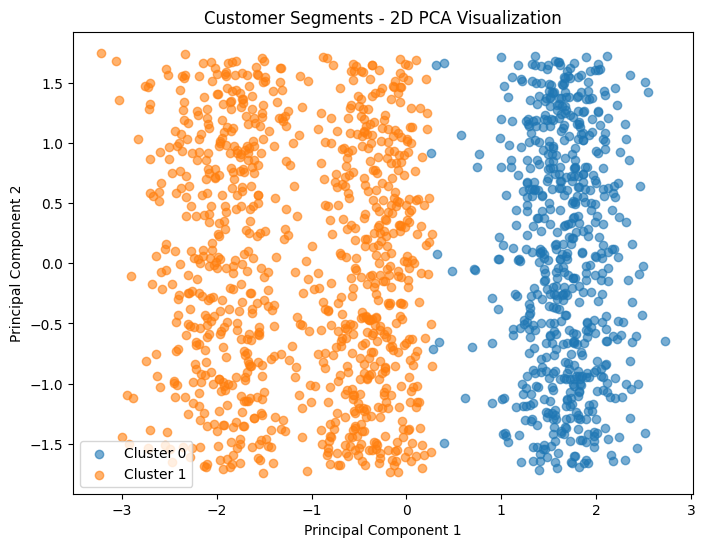

In [42]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Get preprocessed data from the final pipeline
X_prepared = final_pipeline.named_steps["preprocessing"].transform(X)

# Reduce to 2 dimensions only for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_prepared)

plt.figure(figsize=(8, 6))

for cluster in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments - 2D PCA Visualization")
plt.legend()
plt.show()

### E5. Productionization and Visualization

For production, I would monitor the customer data for changes in feature distributions, missing values, cluster sizes, and clustering quality. If significant data drift or changes in customer behaviour are detected, the preprocessing and clustering model should be retrained using recent data. The model should also be versioned so that previous customer segments can be compared with new ones.

If 384-dimensional review embeddings are available, I would add them as another feature group. Because 384 dimensions can be large, I would first normalize the embeddings and reduce their dimensionality using PCA before combining them with the existing customer features. The embedding features should be scaled appropriately so that they do not dominate the numerical customer features.

The 2D PCA visualization helps us visually inspect whether the clusters appear separated. However, it cannot represent all dimensions of the data and should not be used alone to prove that the clusters are meaningful. Business metrics, cluster stability, and customer profiles should also be considered.

## Sources and AI Use Declaration

### Sources
- Scikit-learn documentation was referred to for understanding K-Means, PCA, StandardScaler, DBSCAN, silhouette score, Calinski-Harabasz score, and ARI.
- NumPy and Pandas documentation were referred to for relevant data-processing operations.

### AI Tool Use
AI tools were used to support understanding of concepts, code refactoring, debugging, and improving explanations. The final notebook was reviewed, executed, and verified by Me, and the reported outputs are from my own execution.